In [2]:
import kagglehub
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

path = kagglehub.dataset_download("sahideseker/customer-segmentation-dataset")
print("Dataset download to:", path)

100%|██████████| 9.30k/9.30k [00:00<00:00, 7.17MB/s]

Extracting files...
Dataset download to: /root/.cache/kagglehub/datasets/sahideseker/customer-segmentation-dataset/versions/1


In [ ]:
print(os.listdir(path))
file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(file_path)
df.head()

['13_customer_segmentation.csv']


,customer_id,age,income,spending_score,visits_per_month
0,CUST1000,56,120186,55,9
1,CUST1001,69,49674,80,1
2,CUST1002,46,61271,62,8
3,CUST1003,32,88688,30,6
4,CUST1004,60,126076,55,6


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,age,income,spending_score,visits_per_month
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.81900,83958.460000,48.681000,10.087000
std,14.99103,39293.028951,29.082659,5.543299
min,18.00000,15126.000000,1.000000,1.000000
25%,31.00000,50012.250000,22.000000,5.000000
50%,44.00000,84322.000000,48.000000,10.000000
75%,56.00000,118153.000000,74.000000,15.000000
max,69.00000,149869.000000,99.000000,19.000000


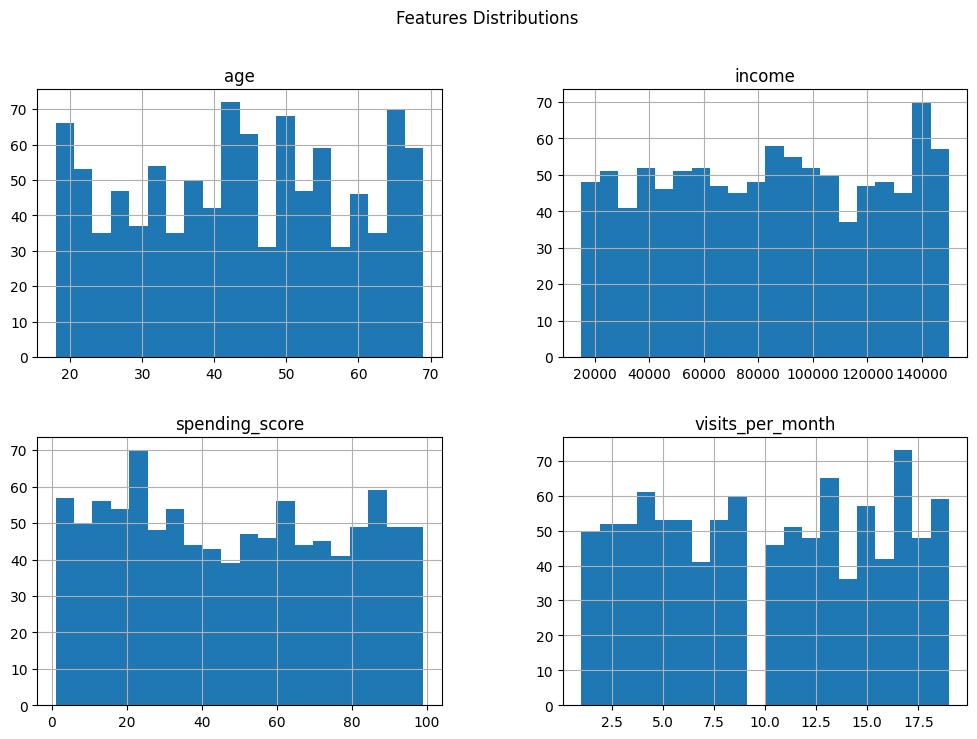

In [ ]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Features Distributions")
plt.show()

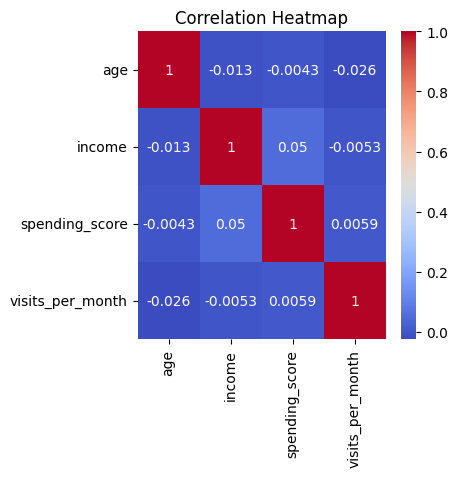

In [ ]:
plt.figure(figsize=(4,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<Figure size 100x100 with 0 Axes>

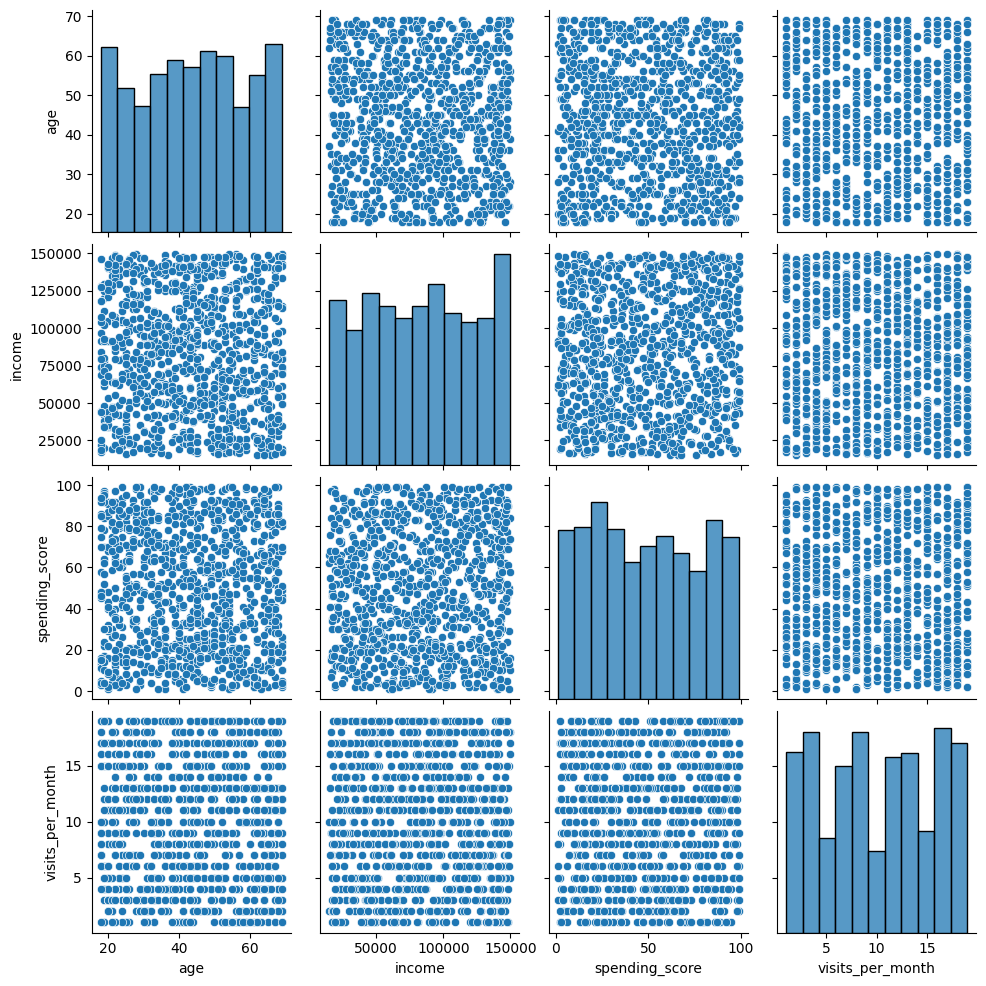

In [ ]:
plt.figure(figsize=(1,1))
sns.pairplot(df.select_dtypes(include=['float64', 'int64']))
plt.show()


In [ ]:
features = df[['age','income','spending_score','visits_per_month']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

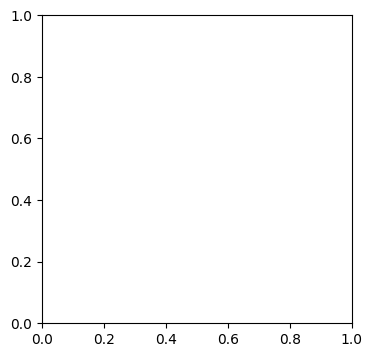

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(4,4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, n_init=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

In [ ]:
plt.figure(figsize=(5,6))
sns.scatterplot(
    x=features.iloc[:,1],
    y=features.iloc[:,0],
    hue='cluster',
    palette='Set1',
    data=df
)
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

ValueError: Could not interpret value `cluster` for `hue`. Value is a string, but `data` was not passed.

<Figure size 500x600 with 0 Axes>

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


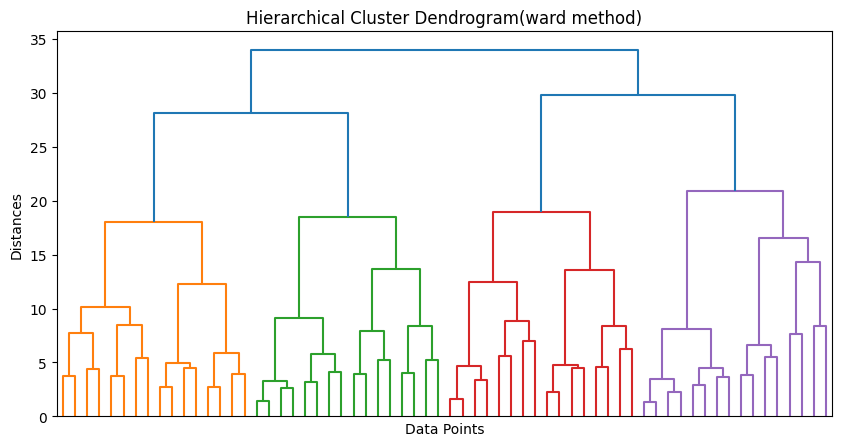

In [ ]:
features = df[['age','income','income','spending_score','visits_per_month']]
features = df.select_dtypes(include=['float64', 'int64'])
features = features.drop(columns=['cluster ID'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

plt.figure(figsize=(10, 5))
linked = linkage(X_scaled, method='ward')

dendrogram(
            linked,
            truncate_mode='level',
            p=5,
           no_labels=True
)

plt.title('Hierarchical Cluster Dendrogram(ward method)')
plt.xlabel('Data Points')
plt.ylabel('Distances')
plt.show()

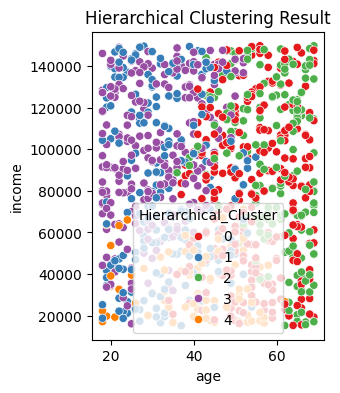

In [ ]:
model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)
df['Hierarchical_Cluster'] = model.fit_predict(X_scaled)
x_feature = features.columns[0]
y_feature = features.columns[1]
plt.figure(figsize=(3,4))
sns.scatterplot(
    data=df,
    x=x_feature,
    y=y_feature,
    hue='Hierarchical_Cluster',
    palette='Set1'
)
plt.title("Hierarchical Clustering Result")
plt.show()

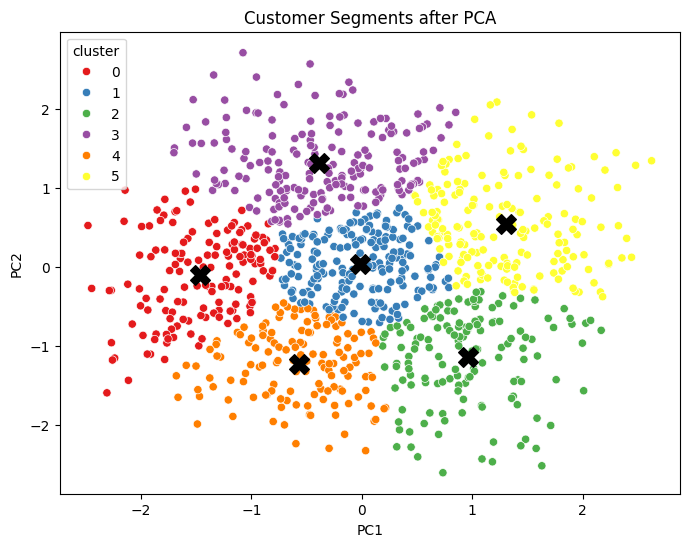

In [ ]:
# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(5,5))

kmeans_pca = KMeans(n_clusters=6, n_init=10, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters_pca

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1'
)
plt.title("PCA Clustering Result")




centroids = kmeans_pca.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)
plt.title("Customer Segments after PCA")
plt.show()

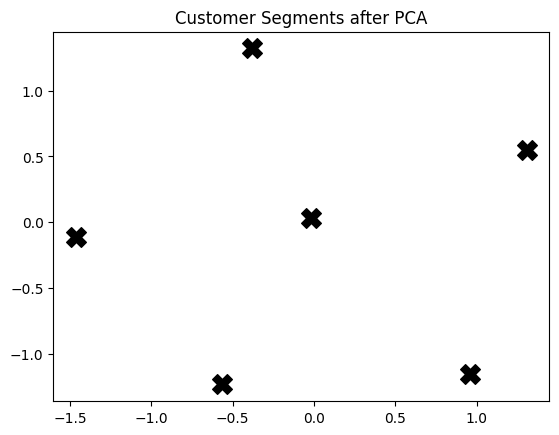

In [ ]:
centroids = kmeans_pca.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)
plt.title("Customer Segments after PCA")
plt.show()

In [3]:
# import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)
#

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path to dataset files: /kaggle/input/customer-personality-analysis
